In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Train.csv")

In [3]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [4]:
df.dtypes

ID                      int64
Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object

In [5]:
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [6]:
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [7]:
df.shape

(10999, 12)

In [8]:
df.iloc[0]

ID                          1
Warehouse_block             D
Mode_of_Shipment       Flight
Customer_care_calls         4
Customer_rating             2
Cost_of_the_Product       177
Prior_purchases             3
Product_importance        low
Gender                      F
Discount_offered           44
Weight_in_gms            1233
Reached.on.Time_Y.N         1
Name: 0, dtype: object

In [9]:
#Sort values by ID
df.sort_values(by="ID",ascending=True)
df.sort_index()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [10]:
#GroupBy Warehouse_block & Customer_rating
df.groupby("Warehouse_block")["Customer_rating"].mean()

Warehouse_block
A    2.957447
B    2.980360
C    2.993999
D    3.017993
F    2.996727
Name: Customer_rating, dtype: float64

In [11]:
df.groupby(["Warehouse_block","Cost_of_the_Product"])["Customer_rating"].sum()

Warehouse_block  Cost_of_the_Product
A                96                      4
                 97                      4
                 98                     19
                 99                      5
                 100                     7
                                        ..
F                306                    25
                 307                    12
                 308                    23
                 309                     7
                 310                    20
Name: Customer_rating, Length: 1032, dtype: int64

In [12]:
# select specific columns 
df[['ID', 'Cost_of_the_Product']]

,ID,Cost_of_the_Product
0,1,177
1,2,216
2,3,183
3,4,176
4,5,184
...,...,...
10994,10995,252
10995,10996,232
10996,10997,242
10997,10998,223


In [13]:
#Filter Values Where cuatomer rating > 3 and mode of shipment is Flight
df[(df['Customer_rating'] > 3) & (df['Mode_of_Shipment'] == 'Flight')]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
6,7,D,Flight,3,4,250,3,low,F,3,2371,1
8,9,A,Flight,3,4,150,3,low,F,11,1861,1
10,11,C,Flight,3,4,189,2,medium,M,12,2888,1
11,12,F,Flight,4,5,232,3,medium,F,32,3253,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10966,10967,C,Flight,5,5,246,5,low,F,6,1300,0
10967,10968,F,Flight,5,4,221,6,medium,M,5,1944,0
10968,10969,D,Flight,4,4,257,5,medium,F,4,1668,0
10970,10971,A,Flight,4,4,216,6,low,M,5,1272,0


In [14]:
#isin()
df[df['Warehouse_block'].isin(['A','B'])]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
8,9,A,Flight,3,4,150,3,low,F,11,1861,1
9,10,B,Flight,3,2,164,3,medium,F,29,1187,1
14,15,A,Flight,4,3,152,3,low,M,43,1009,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10983,10984,B,Ship,4,3,229,6,medium,M,1,1235,1
10988,10989,A,Ship,4,3,192,4,low,F,2,1830,0
10989,10990,B,Ship,5,1,218,5,medium,F,9,1603,0
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1


In [15]:
df['Mode_of_Shipment'].unique()  #distinct mode of shipment

array(['Flight', 'Ship', 'Road'], dtype=object)

In [16]:
#count of unique product importance
df['Product_importance'].value_counts()

Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64

In [17]:
#Sum() - sum of cost of all products 
df['Cost_of_the_Product'].sum()

np.int64(2311955)

In [18]:
#number of unique warehouse blocks
df['Warehouse_block'].nunique()

5

In [19]:
#Groupby 
df.groupby("Product_importance")["Cost_of_the_Product"].median()

Product_importance
high      205.5
low       218.0
medium    213.0
Name: Cost_of_the_Product, dtype: float64

In [20]:
df[df['Customer_rating']>3]['Customer_rating'].value_counts()

Customer_rating
4    2189
5    2171
Name: count, dtype: int64

In [21]:
#LIKE (string contains)
df[df['Mode_of_Shipment'].str.contains('Ship')]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
17,18,F,Ship,5,5,227,3,medium,M,36,3952,1
18,19,D,Ship,5,5,239,3,high,M,18,2495,1
19,20,F,Ship,4,5,145,3,medium,M,45,1059,1
20,21,A,Ship,3,3,161,2,medium,F,38,1521,1
21,22,B,Ship,3,1,232,4,medium,F,51,2899,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [22]:
#map()-mapping the floating number to each element
numbers=[1,2,3,4,5]
list(map(float,numbers))

[1.0, 2.0, 3.0, 4.0, 5.0]

In [23]:
#filter()

In [24]:
numbers = [1,2,4,7,3,50,200]

number_greater_50=list(filter(lambda x:x>50,numbers))

print(number_greater_50)

[200]


In [25]:
#map
number_greater = list(map(lambda x:x>50,numbers))

In [26]:
number_greater

[False, False, False, False, False, False, True]

In [27]:
'''lambda → defines what the function does.

map → where and how to apply that function on a collection.'''

'lambda → defines what the function does.\n\nmap → where and how to apply that function on a collection.'

In [28]:
# regex: helps in filtering / like searching 

In [29]:
df.filter(regex = "C")

,Customer_care_calls,Customer_rating,Cost_of_the_Product
0,4,2,177
1,4,5,216
2,2,2,183
3,3,3,176
4,2,2,184
...,...,...,...
10994,4,1,252
10995,4,1,232
10996,5,4,242
10997,5,2,223


In [30]:
df.filter(regex = "rating")

,Customer_rating
0,2
1,5
2,2
3,3
4,2
...,...
10994,1
10995,1
10996,4
10997,2


In [31]:
#like()
df.filter(like='rating')

,Customer_rating
0,2
1,5
2,2
3,3
4,2
...,...
10994,1
10995,1
10996,4
10997,2


In [32]:
df.iloc[100:,:]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
100,101,C,Ship,5,3,143,2,medium,M,59,1837,1
101,102,F,Ship,5,5,227,4,low,M,53,2624,1
102,103,D,Ship,2,1,213,3,low,M,29,2732,1
103,104,F,Ship,5,1,144,4,low,M,37,1658,1
104,105,A,Ship,3,3,218,3,low,M,3,2255,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [33]:
#str.contains()

df[df['Mode_of_Shipment'].str.contains('hi')]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
17,18,F,Ship,5,5,227,3,medium,M,36,3952,1
18,19,D,Ship,5,5,239,3,high,M,18,2495,1
19,20,F,Ship,4,5,145,3,medium,M,45,1059,1
20,21,A,Ship,3,3,161,2,medium,F,38,1521,1
21,22,B,Ship,3,1,232,4,medium,F,51,2899,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [34]:
#in 
"t" in "infosys"

False

In [35]:
"S" in "Sanika"

True

In [36]:
#created a new column Date_Delivery using date_range()
dates=pd.date_range(start="2025-08-29 00:00",periods=10999,freq="h")
df["Date_Delivery"]=dates

In [37]:
df["Date_Delivery"]

0       2025-08-29 00:00:00
1       2025-08-29 01:00:00
2       2025-08-29 02:00:00
3       2025-08-29 03:00:00
4       2025-08-29 04:00:00
                ...        
10994   2026-11-30 02:00:00
10995   2026-11-30 03:00:00
10996   2026-11-30 04:00:00
10997   2026-11-30 05:00:00
10998   2026-11-30 06:00:00
Name: Date_Delivery, Length: 10999, dtype: datetime64[ns]

In [38]:
#lambda() and capitalize()
words=['apple','banana']
capitalised = list(map(lambda w:w.capitalize(),words))
capitalised

['Apple', 'Banana']

In [39]:
df['Cost_of_the_Product-temp']=df['Cost_of_the_Product'].apply(lambda x:x*2)

In [40]:
df[['Cost_of_the_Product','Cost_of_the_Product-temp']]

,Cost_of_the_Product,Cost_of_the_Product-temp
0,177,354
1,216,432
2,183,366
3,176,352
4,184,368
...,...,...
10994,252,504
10995,232,464
10996,242,484
10997,223,446


In [41]:
#loc()
df.loc[100,['ID','Cost_of_the_Product']]

ID                     101
Cost_of_the_Product    143
Name: 100, dtype: object

In [42]:
df.iloc[1:3:5]

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Date_Delivery,Cost_of_the_Product-temp
1,2,F,Flight,4,5,216,2,low,M,59,3088,1,2025-08-29 01:00:00,432


In [43]:
add_5=lambda x,y : x+y+5
print(add_5(3,5))

13


In [44]:
#Queries 
# 1. Get 3  cheapest products with their weights.
cheapest=df[['Cost_of_the_Product','Weight_in_gms']].nsmallest(3,'Cost_of_the_Product').reset_index(drop=True)
print(cheapest)

   Cost_of_the_Product  Weight_in_gms
0                   96           1294
1                   96           1655
2                   96           1186


In [45]:
# 2. Average customer care calls
avg_calls= df['Customer_care_calls'].mean()
print(avg_calls)

4.054459496317847


In [46]:
# 3. Highest customer rating
max_rating=df['Customer_rating'].max()
print(max_rating)

5


In [47]:
# 4. products delivered on time
on_time=df[df['Reached.on.Time_Y.N']==1]
print(on_time.shape[0])

6563


In [48]:
# 5.Most frequent product importance level

importance_counts=df['Product_importance'].value_counts()
print(importance_counts)

Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64


In [49]:
# 6.Total discount offered by gender
discount_by_gender = df.groupby('Gender')['Discount_offered'].sum()
print(discount_by_gender)

Gender
F    75204
M    71888
Name: Discount_offered, dtype: int64


In [50]:
# 7. Mode of Shipment Distribution
shipment_mode = df['Mode_of_Shipment'].value_counts()
print(shipment_mode)

Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64


In [51]:
# 9. Correlation between cost and weight

correlation = df['Cost_of_the_Product'].corr(df['Weight_in_gms'])
print(correlation)

-0.13260404754942498


In [52]:
# 10.Use lambda with apply → Create a new column for cost category

df['Cost_Category'] = df['Cost_of_the_Product'].apply(lambda x: 'High' if x > 200 else 'Low')
print(df[['Cost_of_the_Product','Cost_Category']])

       Cost_of_the_Product Cost_Category
0                      177           Low
1                      216          High
2                      183           Low
3                      176           Low
4                      184           Low
...                    ...           ...
10994                  252          High
10995                  232          High
10996                  242          High
10997                  223          High
10998                  155           Low

[10999 rows x 2 columns]


In [53]:
# 11.Use map → Convert Gender values to full form
df['Gender_Full'] = df['Gender'].map({'M':'Male','F':'Female'})
print(df[['Gender','Gender_Full']])

      Gender Gender_Full
0          F      Female
1          M        Male
2          M        Male
3          M        Male
4          F      Female
...      ...         ...
10994      F      Female
10995      F      Female
10996      F      Female
10997      M        Male
10998      F      Female

[10999 rows x 2 columns]


In [54]:
#Converts raw discounts into percentage values.
df['Discount_percent'] = df['Discount_offered'].apply(lambda x: (x/100))
print(df[['Discount_offered','Discount_percent']])

       Discount_offered  Discount_percent
0                    44              0.44
1                    59              0.59
2                    48              0.48
3                    10              0.10
4                    46              0.46
...                 ...               ...
10994                 1              0.01
10995                 6              0.06
10996                 4              0.04
10997                 2              0.02
10998                 6              0.06

[10999 rows x 2 columns]


In [55]:
df.shape

(10999, 17)

In [56]:
# Assume missing ratings are filled with average
df['Customer_rating'] = df['Customer_rating'].fillna(df['Customer_rating'].mean())

In [57]:
#astype() → Change datatype
# df['Customer_care_calls'] = df['Customer_care_calls'].astype(float)
#print(df.dtypes)

In [58]:
#pivote table 
#Example 1: Average product cost per shipment mode

pivot1 = df.pivot_table(
    values='Cost_of_the_Product',
    index='Mode_of_Shipment',
    aggfunc='mean'
)
print(pivot1)

#This will show the average Cost_of_the_Product for each Mode_of_Shipment (e.g., Flight, Ship, Road, etc.).
#Pivot tables in Pandas are super useful when you want to summarize data (like SQL GROUP BY) and get meaningful insights.

                  Cost_of_the_Product
Mode_of_Shipment                     
Flight                     209.306697
Road                       210.475568
Ship                       210.343072


In [59]:
# important features present in our dataset
'''Mode_of_Shipment

Customer_care_calls

Discount_offered

Weight_in_gms

Customer_rating

Product_importance'''

'Mode_of_Shipment\n\nCustomer_care_calls\n\nDiscount_offered\n\nWeight_in_gms\n\nCustomer_rating\n\nProduct_importance'

In [60]:
#features that we can create 
# 1. Total Cost after Discount

df['Final_Price'] = df['Cost_of_the_Product'] - df['Discount_offered']
print(df[['Cost_of_the_Product', 'Discount_offered', 'Final_Price']].head())

   Cost_of_the_Product  Discount_offered  Final_Price
0                  177                44          133
1                  216                59          157
2                  183                48          135
3                  176                10          166
4                  184                46          138


In [61]:
#Customer Satisfaction Flag
df['Satisfied_Customer'] = df['Customer_rating'].apply(lambda x: 1 if x >= 4 else 0)
print(df[['Customer_rating','Satisfied_Customer']].head())
#New binary column: 1 = satisfied, 0 = not.

   Customer_rating  Satisfied_Customer
0                2                   0
1                5                   1
2                2                   0
3                3                   0
4                2                   0


In [62]:
#discount percentages
#Helps to analyze whether higher discounts lead to better delivery or satisfaction.

df['Discount_Percent'] = (df['Discount_offered'] / df['Cost_of_the_Product']) * 100
print(df[['Cost_of_the_Product','Discount_offered','Discount_Percent']].head())

   Cost_of_the_Product  Discount_offered  Discount_Percent
0                  177                44         24.858757
1                  216                59         27.314815
2                  183                48         26.229508
3                  176                10          5.681818
4                  184                46         25.000000


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df.describe()         # Statistical summary (mean, std, quartiles)

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Date_Delivery,Cost_of_the_Product-temp,Discount_percent,Final_Price,Satisfied_Customer,Discount_Percent
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691,2026-04-15 03:00:00,420.393672,0.133732,196.823620,0.396400,7.023666
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000,2025-08-29 00:00:00,192.000000,0.010000,36.000000,0.000000,0.322581
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000,2025-12-21 13:30:00,338.000000,0.040000,155.000000,0.000000,1.754386
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000,2026-04-15 03:00:00,428.000000,0.070000,200.000000,0.000000,3.333333
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000,2026-08-07 16:30:00,502.000000,0.100000,241.000000,1.000000,6.296459
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000,2026-11-30 06:00:00,620.000000,0.650000,309.000000,1.000000,63.636364
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584,NaN,96.126544,0.162055,52.802998,0.489171,9.268773


<Axes: xlabel='Cost_of_the_Product', ylabel='Count'>

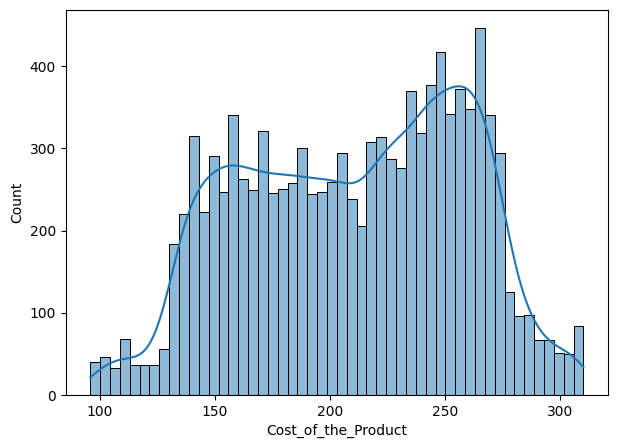

In [65]:
plt.figure(figsize=(7,5))
sns.histplot(df['Cost_of_the_Product'],bins=50,kde=True) #
# Interpretation: See if product cost follows normal or skewed distribution

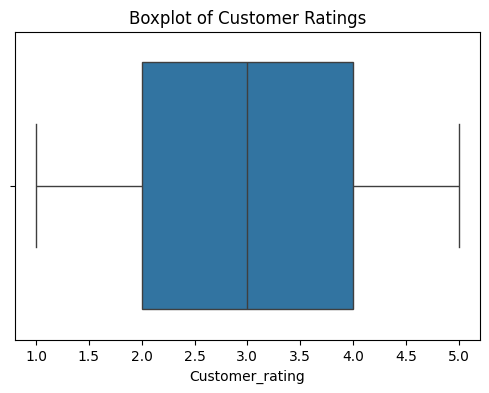

In [66]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Customer_rating"])
plt.title("Boxplot of Customer Ratings")
plt.show()
# Interpretation: Boxplot helps detect outliers in customer ratings

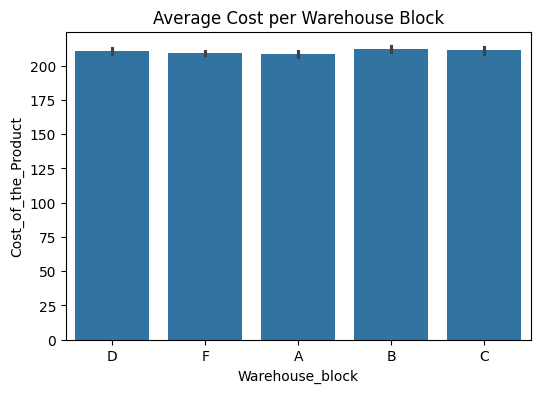

In [67]:
plt.figure(figsize=(6,4))
sns.barplot(x="Warehouse_block", y="Cost_of_the_Product", data=df)
plt.title("Average Cost per Warehouse Block")
plt.show()
# Interpretation: Compares avg. product cost across warehouses

<Axes: xlabel='Mode_of_Shipment', ylabel='count'>

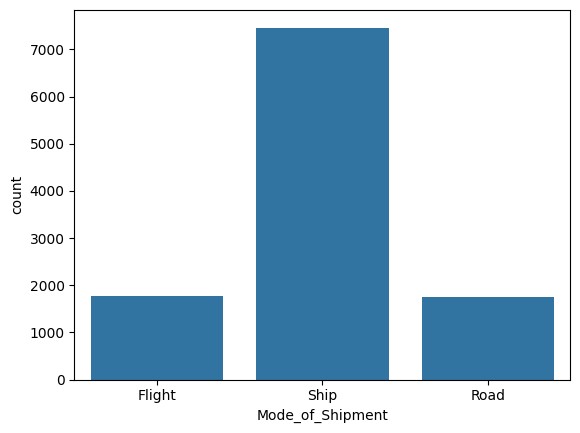

In [68]:
sns.countplot(x='Mode_of_Shipment',data=df)

<Axes: xlabel='Cost_of_the_Product'>

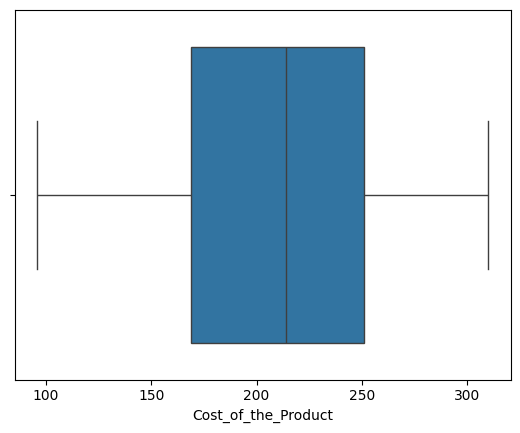

In [69]:
sns.boxplot(x='Cost_of_the_Product',data=df)


<Axes: xlabel='Warehouse_block', ylabel='Customer_care_calls'>

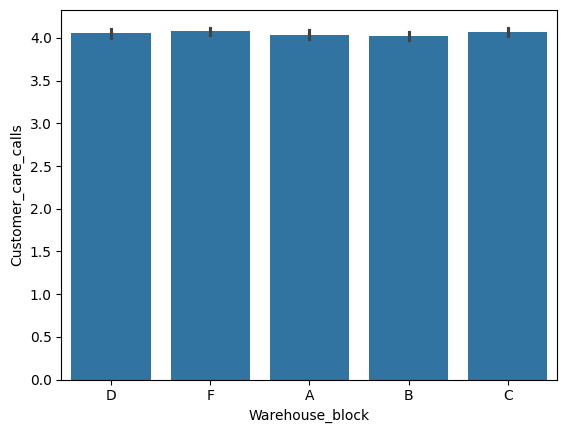

In [70]:
sns.barplot(x = 'Warehouse_block', y = 'Customer_care_calls', data = df)

<Axes: xlabel='Cost_of_the_Product'>

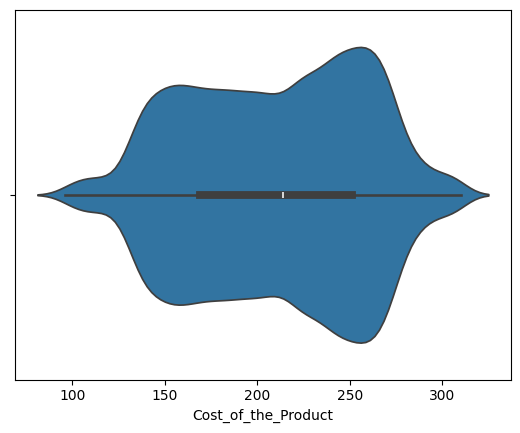

In [71]:
sns.violinplot(x='Cost_of_the_Product',data=df)

<Axes: xlabel='Prior_purchases', ylabel='Cost_of_the_Product'>

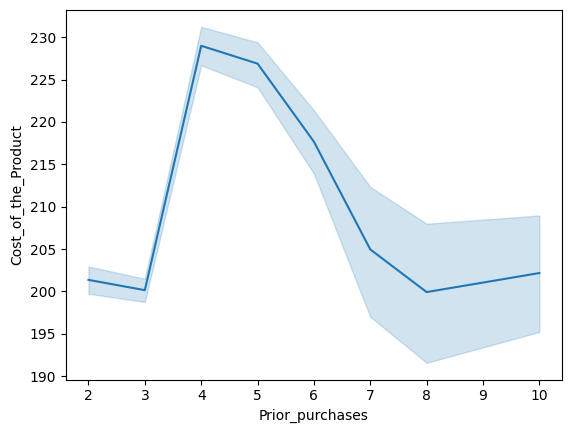

In [72]:
sns.lineplot(x='Prior_purchases',y='Cost_of_the_Product',data=df)

<Axes: xlabel='Cost_of_the_Product', ylabel='Weight_in_gms'>

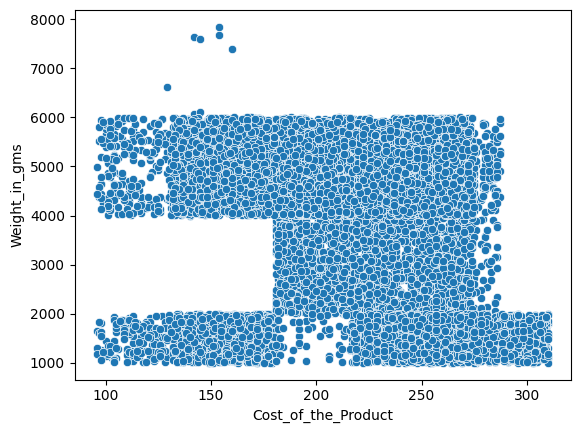

In [73]:
#RELATIONSHIPS BETWEEN VARIABLES
sns.scatterplot(x='Cost_of_the_Product',y='Weight_in_gms',data=df)

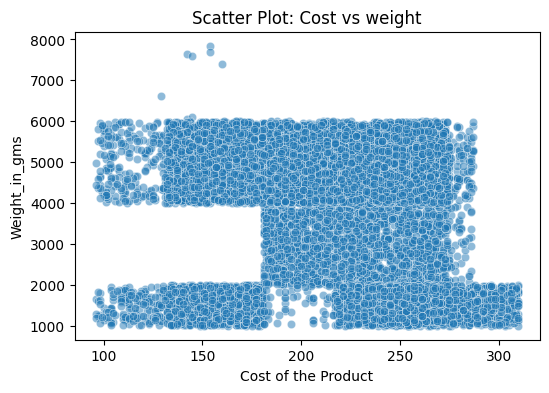

In [74]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="Cost_of_the_Product", 
    y="Weight_in_gms", 
    data=df,
    alpha=0.5   # transparency (0 = fully transparent, 1 = solid)
)
plt.title("Scatter Plot: Cost vs weight")
plt.xlabel("Cost of the Product")
plt.ylabel("Weight_in_gms")
plt.show()

#Without alpha: all points look the same color, and dense areas aren’t obvious.
#With alpha < 1: overlapping areas become darker, showing where more points are concentrated.

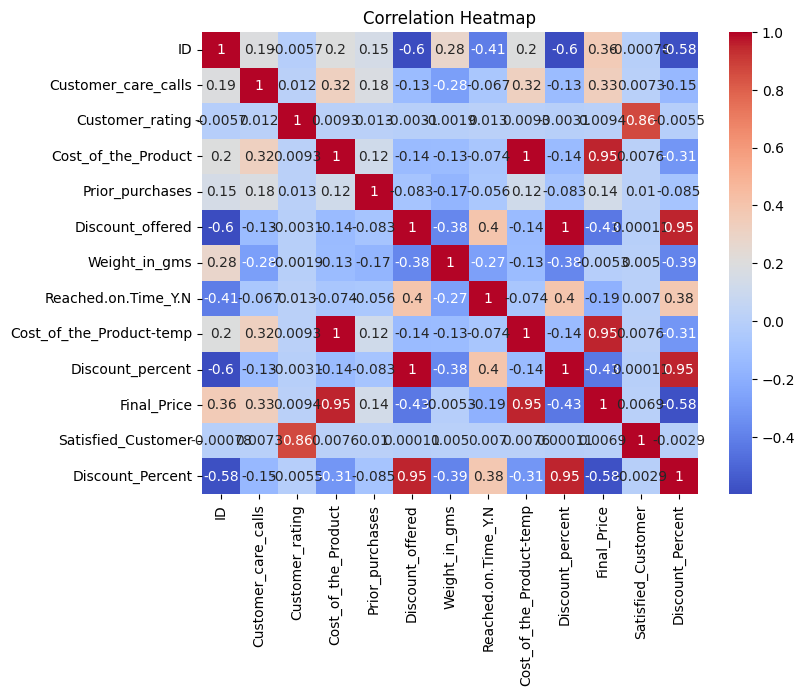

In [75]:
# CORRELATION HEATMAP
# -------------------------------
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
# Interpretation: Look for strong correlations (close to +1 or -1) between numerical columns

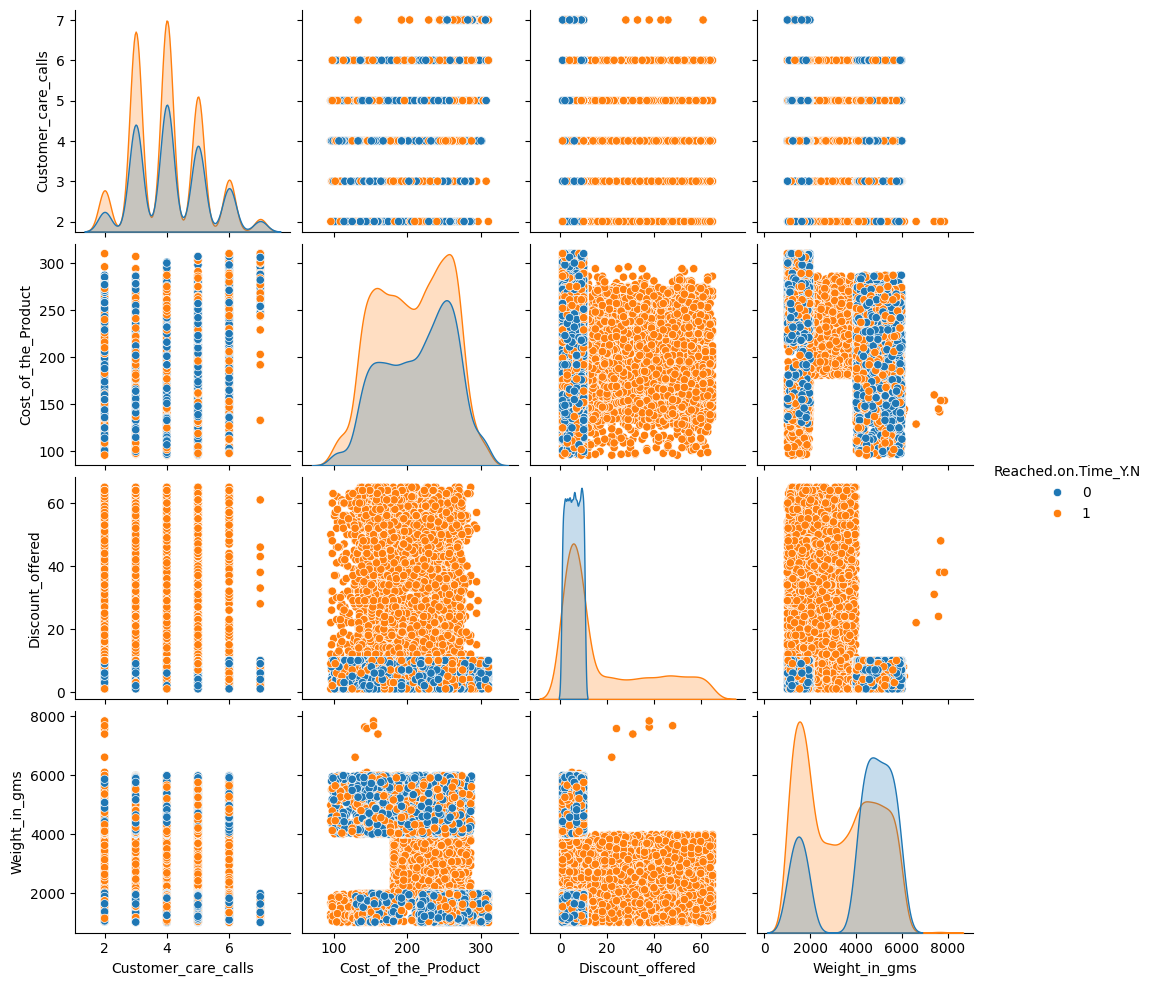

In [76]:
num_cols=['Customer_care_calls','Cost_of_the_Product','Discount_offered','Weight_in_gms','Reached.on.Time_Y.N']
sns.pairplot(df[num_cols],
             hue= 'Reached.on.Time_Y.N')

In [77]:
df.isnull().sum()

ID                          0
Warehouse_block             0
Mode_of_Shipment            0
Customer_care_calls         0
Customer_rating             0
Cost_of_the_Product         0
Prior_purchases             0
Product_importance          0
Gender                      0
Discount_offered            0
Weight_in_gms               0
Reached.on.Time_Y.N         0
Date_Delivery               0
Cost_of_the_Product-temp    0
Cost_Category               0
Gender_Full                 0
Discount_percent            0
Final_Price                 0
Satisfied_Customer          0
Discount_Percent            0
dtype: int64

In [78]:
df.shape

(10999, 20)

# Feature Engineering - creating new featurs from the dataset

In [79]:
#Cost per Gram → captures how expensive a product is relative to its weight.
df['Cost_per_grams']=df['Cost_of_the_Product']/df['Weight_in_gms']

In [80]:
# Discounted Price → effective price after discount.
df['Discounted_Price'] = df['Cost_of_the_Product'] - df['Discount_offered']

In [81]:
# Discount Percentage → shows how big the discount is.
df['Discount_Percentage'] = (df['Discount_offered'] / df['Cost_of_the_Product']) * 100

In [82]:
# High Weight Flag → to capture heavy parcels.
df['Heavy_Shipment'] = (df['Weight_in_gms'] > 2500).astype(int)

In [83]:
# High Discount Flag → to check if discounts affect delays.
df['High_Discount'] = (df['Discount_offered'] > 30).astype(int)

In [84]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,...,Gender_Full,Discount_percent,Final_Price,Satisfied_Customer,Discount_Percent,Cost_per_grams,Discounted_Price,Discount_Percentage,Heavy_Shipment,High_Discount
0,1,D,Flight,4,2,177,3,low,F,44,...,Female,0.44,133,0,24.858757,0.143552,133,24.858757,0,1
1,2,F,Flight,4,5,216,2,low,M,59,...,Male,0.59,157,1,27.314815,0.069948,157,27.314815,1,1
2,3,A,Flight,2,2,183,4,low,M,48,...,Male,0.48,135,0,26.229508,0.054238,135,26.229508,1,1
3,4,B,Flight,3,3,176,4,medium,M,10,...,Male,0.10,166,0,5.681818,0.149533,166,5.681818,0,0
4,5,C,Flight,2,2,184,3,medium,F,46,...,Female,0.46,138,0,25.000000,0.074074,138,25.000000,0,1


In [85]:
df.shape

(10999, 25)

# Imputation

In [86]:
import pandas as pd
import numpy as np

# Create sample data
data = {
    'Age': [25, 30, np.nan, 40, 35, np.nan, 28],
    'Salary': [50000, 60000, 55000, np.nan, 65000, 70000, np.nan],
    'Department': ['HR', 'IT', 'Finance', np.nan, 'Finance', 'IT', 'HR']
}

df2 = pd.DataFrame(data)
print("Original Dataset with Missing Values:\n")
print(df2)

Original Dataset with Missing Values:

    Age   Salary Department
0  25.0  50000.0         HR
1  30.0  60000.0         IT
2   NaN  55000.0    Finance
3  40.0      NaN        NaN
4  35.0  65000.0    Finance
5   NaN  70000.0         IT
6  28.0      NaN         HR


In [87]:
print("\nMissing Values Count:\n")
print(df2.isnull().sum())


Missing Values Count:

Age           2
Salary        2
Department    1
dtype: int64


In [88]:
# 1. Mean Imputation (for Age)
df2['Age_mean'] = df2['Age'].fillna(df2['Age'].mean())
print("\nAfter Mean Imputation (Age):\n", df2[['Age', 'Age_mean']])

# 2. Median Imputation (for Age)
df2['Age_median'] = df2['Age'].fillna(df2['Age'].median())
print("\nAfter Median Imputation (Age):\n", df2[['Age', 'Age_median']])

# 3. Mode Imputation (for Department)
df2['Department_mode'] = df2['Department'].fillna(df2['Department'].mode()[0])
print("\nAfter Mode Imputation (Department):\n", df2[['Department', 'Department_mode']])


After Mean Imputation (Age):
     Age  Age_mean
0  25.0      25.0
1  30.0      30.0
2   NaN      31.6
3  40.0      40.0
4  35.0      35.0
5   NaN      31.6
6  28.0      28.0

After Median Imputation (Age):
     Age  Age_median
0  25.0        25.0
1  30.0        30.0
2   NaN        30.0
3  40.0        40.0
4  35.0        35.0
5   NaN        30.0
6  28.0        28.0

After Mode Imputation (Department):
   Department Department_mode
0         HR              HR
1         IT              IT
2    Finance         Finance
3        NaN         Finance
4    Finance         Finance
5         IT              IT
6         HR              HR


In [89]:
# 4. Forward Fill (for Salary)
df2['Salary_ffill'] = df2['Salary'].fillna(method='ffill')
print("\nAfter Forward Fill (Salary):\n", df2[['Salary', 'Salary_ffill']])

# 5. Backward Fill (for Salary)
df2['Salary_bfill'] = df2['Salary'].fillna(method='bfill')
print("\nAfter Backward Fill (Salary):\n", df2[['Salary', 'Salary_bfill']])


After Forward Fill (Salary):
     Salary  Salary_ffill
0  50000.0       50000.0
1  60000.0       60000.0
2  55000.0       55000.0
3      NaN       55000.0
4  65000.0       65000.0
5  70000.0       70000.0
6      NaN       70000.0

After Backward Fill (Salary):
     Salary  Salary_bfill
0  50000.0       50000.0
1  60000.0       60000.0
2  55000.0       55000.0
3      NaN       65000.0
4  65000.0       65000.0
5  70000.0       70000.0
6      NaN           NaN


C:\Users\Admin\AppData\Local\Temp\ipykernel_23960\1608552588.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df2['Salary_ffill'] = df2['Salary'].fillna(method='ffill')
C:\Users\Admin\AppData\Local\Temp\ipykernel_23960\1608552588.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df2['Salary_bfill'] = df2['Salary'].fillna(method='bfill')


In [90]:
from sklearn.impute import SimpleImputer
# 6. SimpleImputer (mean strategy for Salary)

#The SimpleImputer is a preprocessing tool in sklearn.impute used to handle missing values in a dataset.

imputer_mean = SimpleImputer(strategy='mean')
df2['Salary_imputed'] = imputer_mean.fit_transform(df2[['Salary']])
print("\nAfter SimpleImputer Mean (Salary):\n", df2[['Salary', 'Salary_imputed']])


After SimpleImputer Mean (Salary):
     Salary  Salary_imputed
0  50000.0         50000.0
1  60000.0         60000.0
2  55000.0         55000.0
3      NaN         60000.0
4  65000.0         65000.0
5  70000.0         70000.0
6      NaN         60000.0


In [91]:
# interpolation : Interpolation is the process of estimating an unknown data point that falls between two or more known data points, creating a new point within the existing range of data

In [93]:
# Linear, Polynomial, and Spline Interpolation Example

import pandas as pd
import numpy as np

# Sample dataset with missing values
data = {
    'Day': [1, 2, 3, 4, 5, 6, 7],
    'Temperature': [30, np.nan, 32, np.nan, 35, 36, np.nan]
}

df_interpolation = pd.DataFrame(data)
print("Before Interpolation:\n", df_interpolation)

#  Linear Interpolation
df_interpolation['Temperature_linear'] = df_interpolation['Temperature'].interpolate(method='linear')
print("\nAfter Linear Interpolation:\n", df_interpolation)

# Polynomial Interpolation (order 2 = quadratic curve)
df_interpolation['Temperature_poly'] = df_interpolation['Temperature'].interpolate(method='polynomial', order=2)

#  Spline Interpolation (order 2 = quadratic spline)
df_interpolation['Temperature_spline'] = df_interpolation['Temperature'].interpolate(method='spline', order=2)

print("\nAfter Polynomial & Spline Interpolation:\n", df_interpolation)

Before Interpolation:
    Day  Temperature
0    1         30.0
1    2          NaN
2    3         32.0
3    4          NaN
4    5         35.0
5    6         36.0
6    7          NaN

After Linear Interpolation:
    Day  Temperature  Temperature_linear
0    1         30.0                30.0
1    2          NaN                31.0
2    3         32.0                32.0
3    4          NaN                33.5
4    5         35.0                35.0
5    6         36.0                36.0
6    7          NaN                36.0

After Polynomial & Spline Interpolation:
    Day  Temperature  Temperature_linear  Temperature_poly  Temperature_spline
0    1         30.0                30.0         30.000000           30.000000
1    2          NaN                31.0         30.823529           31.020101
2    3         32.0                32.0         32.000000           32.000000
3    4          NaN                33.5         33.529412           33.414573
4    5         35.0               

# Last missing value (Day 7) stays NaN, since interpolation needs values before & after to calculate.

In [97]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,...,Gender_Full,Discount_percent,Final_Price,Satisfied_Customer,Discount_Percent,Cost_per_grams,Discounted_Price,Discount_Percentage,Heavy_Shipment,High_Discount
0,1,D,Flight,4,2,177,3,low,F,44,...,Female,0.44,133,0,24.858757,0.143552,133,24.858757,0,1
1,2,F,Flight,4,5,216,2,low,M,59,...,Male,0.59,157,1,27.314815,0.069948,157,27.314815,1,1
2,3,A,Flight,2,2,183,4,low,M,48,...,Male,0.48,135,0,26.229508,0.054238,135,26.229508,1,1
3,4,B,Flight,3,3,176,4,medium,M,10,...,Male,0.10,166,0,5.681818,0.149533,166,5.681818,0,0
4,5,C,Flight,2,2,184,3,medium,F,46,...,Female,0.46,138,0,25.000000,0.074074,138,25.000000,0,1


### Encoding and scaling for feature engineering

In [99]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load dataset
df = pd.read_csv("Train.csv")

# Separate features and target (assuming target is Reached.on.Time_Y.N)
X = df.drop(columns=['Reached.on.Time_Y.N'])
y = df['Reached.on.Time_Y.N']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# --------------------------
# Encoding Variants
# --------------------------

# 1. Label Encoding
X_label_encoded = X.copy()
for col in categorical_cols:
    le = LabelEncoder()
    X_label_encoded[col] = le.fit_transform(X_label_encoded[col])

# 2. One-Hot Encoding
onehot_encoder = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
], remainder='passthrough')

# 3. Ordinal Encoding
ordinal_encoder = ColumnTransformer([
    ('ordinal', OrdinalEncoder(), categorical_cols)
], remainder='passthrough')

# --------------------------
# Scaling Pipelines
# --------------------------
# Standardization
std_pipeline = Pipeline(steps=[
    ('encoder', onehot_encoder),
    ('scaler', StandardScaler())
])

# Normalization
norm_pipeline = Pipeline(steps=[
    ('encoder', onehot_encoder),
    ('scaler', MinMaxScaler())
])

# --------------------------
# Apply transformations
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Standardization
X_train_std = std_pipeline.fit_transform(X_train)
X_train_std_df = pd.DataFrame(X_train_std)

# Apply Normalization
X_train_norm = norm_pipeline.fit_transform(X_train)
X_train_norm_df = pd.DataFrame(X_train_norm)

# --------------------------
# Show Outputs
# --------------------------
print("Before Encoding & Scaling:\n", X_train.head(3))
print("\nAfter One-Hot + Standardization:\n", X_train_std_df.head(3))
print("\nAfter One-Hot + Normalization:\n", X_train_norm_df.head(3))


Before Encoding & Scaling:
           ID Warehouse_block Mode_of_Shipment  Customer_care_calls  \
8965    8966               F             Ship                    3   
5936    5937               A             Ship                    6   
10656  10657               D             Ship                    2   

       Customer_rating  Cost_of_the_Product  Prior_purchases  \
8965                 5                  178                3   
5936                 3                  202                4   
10656                5                  277                3   

      Product_importance Gender  Discount_offered  Weight_in_gms  
8965                 low      F                 7           4135  
5936              medium      F                 3           4496  
10656             medium      M                 6           1032  

After One-Hot + Standardization:
          0         1         2         3         4         5         6   \
0 -0.444924 -0.447854 -0.450959  1.417838 -0.433509  0.6

### manual implementations of Target-Guided Encoding
### Mean Encoding → Replace each category with the mean of the target for that category.
### Probability Ratio Encoding (PRE) → Encode as log( P(1|cat) / P(0|cat) ).
### Rank Order Encoding → Rank categories based on mean target values.

In [100]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("Train.csv")

# Separate features and target
X = df.drop(columns=['Reached.on.Time_Y.N'])
y = df['Reached.on.Time_Y.N']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# ==============================
# 1. Mean Encoding
# ==============================
# Replace category with mean of target variable for that category
X_mean_encoded = X.copy()
for col in categorical_cols:
    mean_map = df.groupby(col)['Reached.on.Time_Y.N'].mean()
    X_mean_encoded[col] = X_mean_encoded[col].map(mean_map)

# ==============================
# 2. Probability Ratio Encoding (PRE)
# ==============================
# Formula: log(P(1|cat) / P(0|cat))
X_pre_encoded = X.copy()
for col in categorical_cols:
    prob_df = df.groupby(col)['Reached.on.Time_Y.N'].mean()
    prob_ratio = prob_df / (1 - prob_df)
    X_pre_encoded[col] = X_pre_encoded[col].map(prob_ratio)

# ==============================
# 3. Rank Order Encoding
# ==============================
# Replace categories by their rank based on mean target
X_rank_encoded = X.copy()
for col in categorical_cols:
    rank_map = df.groupby(col)['Reached.on.Time_Y.N'].mean().rank().to_dict()
    X_rank_encoded[col] = X_rank_encoded[col].map(rank_map)

# ==============================
# Show Results
# ==============================
print("Original Data (first 5 rows):")
print(X[categorical_cols].head(), "\n")

print("Mean Encoded (first 5 rows):")
print(X_mean_encoded[categorical_cols].head(), "\n")

print("Probability Ratio Encoded (first 5 rows):")
print(X_pre_encoded[categorical_cols].head(), "\n")

print("Rank Order Encoded (first 5 rows):")
print(X_rank_encoded[categorical_cols].head(), "\n")


Original Data (first 5 rows):
  Warehouse_block Mode_of_Shipment Product_importance Gender
0               D           Flight                low      F
1               F           Flight                low      M
2               A           Flight                low      M
3               B           Flight             medium      M
4               C           Flight             medium      F 

Mean Encoded (first 5 rows):
   Warehouse_block  Mode_of_Shipment  Product_importance    Gender
0         0.597601          0.601576            0.592788  0.594409
1         0.598472          0.601576            0.592788  0.599010
2         0.586470          0.601576            0.592788  0.599010
3         0.602291          0.601576            0.590450  0.599010
4         0.596836          0.601576            0.590450  0.594409 

Probability Ratio Encoded (first 5 rows):
   Warehouse_block  Mode_of_Shipment  Product_importance    Gender
0         1.485095          1.509887            1.455726  1.

In [101]:
# Mean Encoding: Captures how strongly each category is associated with the target (average probability of target=1 for that category).
# Probability Ratio Encoding (PRE): Highlights the likelihood of category belonging to class 1 vs 0. Values >> 1 → category leans towards 1.
# Rank Order Encoding: Converts categories into ordered ranks (lowest → highest) based on mean target. Useful when ordinal relation helps.

In [108]:
# Define X and y (using encoded dataset)
X = X_mean_encoded.copy()
y = df['Reached.on.Time_Y.N']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Feature Selection

In [109]:
# 1. Filter Method – Variance Threshold
# Removes features with very low variance (almost constant → not useful).

In [110]:

from sklearn.feature_selection import VarianceThreshold

# Use only numeric columns for variance threshold
X_num = X_mean_encoded.select_dtypes(include=['int64','float64'])

# Variance Threshold
selector = VarianceThreshold(threshold=0.01)  # remove low-variance features
X_var = selector.fit_transform(X_num)

print("=== Filter Method: Variance Threshold ===")
print("Original shape:", X_num.shape)
print("After selection:", X_var.shape)
print("Selected features:", X_num.columns[selector.get_support(indices=True)].tolist())


=== Filter Method: Variance Threshold ===
Original shape: (10999, 11)
After selection: (10999, 7)
Selected features: ['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']


In [111]:
# 2. Embedded Method – Using RandomForest
# Features are ranked by importance (Gini / Entropy).

from sklearn.ensemble import RandomForestClassifier

# Fit RandomForest on encoded + numeric data
rf = RandomForestClassifier(random_state=42)
rf.fit(X_mean_encoded, y)

importances = pd.Series(rf.feature_importances_, index=X_mean_encoded.columns)
importances = importances.sort_values(ascending=False)

print("=== Embedded Method: RandomForest Feature Importance ===")
print(importances.head(10))


=== Embedded Method: RandomForest Feature Importance ===
ID                     0.269464
Weight_in_gms          0.191730
Discount_offered       0.156723
Cost_of_the_Product    0.131205
Warehouse_block        0.047638
Customer_rating        0.045431
Prior_purchases        0.044274
Customer_care_calls    0.041375
Mode_of_Shipment       0.027489
Product_importance     0.024459
dtype: float64


In [112]:
# 3. Wrapper Methods

# (a) Forward Selection
# Start with no features → keep adding the one that improves the model most.

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)

# Forward selection
sfs_forward = SequentialFeatureSelector(logreg, n_features_to_select=5, direction='forward')
sfs_forward.fit(X_mean_encoded, y)

print("=== Wrapper Method: Forward Selection ===")
print("Selected features:", X_mean_encoded.columns[sfs_forward.get_support()].tolist())


=== Wrapper Method: Forward Selection ===
Selected features: ['ID', 'Customer_rating', 'Prior_purchases', 'Product_importance', 'Gender']


In [115]:
# b) Backward Elimination
from sklearn.metrics import accuracy_score
# Logistic Regression with higher iterations
logreg = LogisticRegression(max_iter=5000, solver='lbfgs', random_state=42)

# Backward Elimination
sfs_backward = SequentialFeatureSelector(logreg, n_features_to_select=5, direction='backward')
sfs_backward.fit(X_train_scaled, y_train)

X_train_backward = sfs_backward.transform(X_train_scaled)
X_test_backward = sfs_backward.transform(X_test_scaled)

logreg.fit(X_train_backward, y_train)
y_pred_backward = logreg.predict(X_test_backward)
acc_backward = accuracy_score(y_test, y_pred_backward)

print("=== Wrapper Method: Backward Elimination ===")
print("Selected features:", X.columns[sfs_backward.get_support()].tolist())
print("Accuracy:", acc_backward)

=== Wrapper Method: Backward Elimination ===
Selected features: ['ID', 'Customer_care_calls', 'Product_importance', 'Discount_offered', 'Weight_in_gms']
Accuracy: 0.6624242424242425


In [116]:
# (c) Recursive Feature Elimination (RFE)
# Iteratively remove weakest features until desired number is left.

from sklearn.feature_selection import RFE

# Recursive Feature Elimination
rfe = RFE(logreg, n_features_to_select=5)
rfe.fit(X_mean_encoded, y)

print("=== Wrapper Method: RFE ===")
print("Selected features:", X_mean_encoded.columns[rfe.support_].tolist())


=== Wrapper Method: RFE ===
Selected features: ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender', 'Discount_offered']


In [117]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold, RFE, SequentialFeatureSelector
from sklearn.metrics import accuracy_score

# ==============================
# Prepare data
# ==============================
X = X_mean_encoded.copy()   # using Mean Encoding version
y = df['Reached.on.Time_Y.N']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale numeric features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression base model
logreg = LogisticRegression(max_iter=1000, random_state=42)

# ==============================
# 1. Filter Method (Variance Threshold)
# ==============================
selector_var = VarianceThreshold(threshold=0.01)
X_train_var = selector_var.fit_transform(X_train_scaled)
X_test_var = selector_var.transform(X_test_scaled)

logreg.fit(X_train_var, y_train)
y_pred_var = logreg.predict(X_test_var)
acc_var = accuracy_score(y_test, y_pred_var)

# ==============================
# 2. Embedded Method (RandomForest)
# ==============================
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Select top 5 important features
top_features = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(5).index
X_train_emb = X_train[top_features]
X_test_emb = X_test[top_features]

logreg.fit(X_train_emb, y_train)
y_pred_emb = logreg.predict(X_test_emb)
acc_emb = accuracy_score(y_test, y_pred_emb)

# ==============================
# 3. Wrapper Method
# ==============================
# Forward Selection
sfs_forward = SequentialFeatureSelector(logreg, n_features_to_select=5, direction='forward')
sfs_forward.fit(X_train_scaled, y_train)
X_train_forward = sfs_forward.transform(X_train_scaled)
X_test_forward = sfs_forward.transform(X_test_scaled)

logreg.fit(X_train_forward, y_train)
y_pred_forward = logreg.predict(X_test_forward)
acc_forward = accuracy_score(y_test, y_pred_forward)

# Backward Elimination
sfs_backward = SequentialFeatureSelector(logreg, n_features_to_select=5, direction='backward')
sfs_backward.fit(X_train_scaled, y_train)
X_train_backward = sfs_backward.transform(X_train_scaled)
X_test_backward = sfs_backward.transform(X_test_scaled)

logreg.fit(X_train_backward, y_train)
y_pred_backward = logreg.predict(X_test_backward)
acc_backward = accuracy_score(y_test, y_pred_backward)

# Recursive Feature Elimination (RFE)
rfe = RFE(logreg, n_features_to_select=5)
rfe.fit(X_train_scaled, y_train)
X_train_rfe = rfe.transform(X_train_scaled)
X_test_rfe = rfe.transform(X_test_scaled)

logreg.fit(X_train_rfe, y_train)
y_pred_rfe = logreg.predict(X_test_rfe)
acc_rfe = accuracy_score(y_test, y_pred_rfe)

# ==============================
# Results Comparison
# ==============================
print("\n=== Model Accuracy with Different Feature Selection Methods ===")
print(f"Filter Method (Variance Threshold): {acc_var:.4f}")
print(f"Embedded Method (RandomForest Importance): {acc_emb:.4f}")
print(f"Wrapper Method - Forward Selection: {acc_forward:.4f}")
print(f"Wrapper Method - Backward Elimination: {acc_backward:.4f}")
print(f"Wrapper Method - RFE: {acc_rfe:.4f}")



=== Model Accuracy with Different Feature Selection Methods ===
Filter Method (Variance Threshold): 0.6627
Embedded Method (RandomForest Importance): 0.6670
Wrapper Method - Forward Selection: 0.6539
Wrapper Method - Backward Elimination: 0.6624
Wrapper Method - RFE: 0.6606


### Hypothesis Testing

In [121]:
# ==============================
# Hypothesis Testing on Shipping Dataset
# ==============================
import pandas as pd
from scipy.stats import ttest_ind, chi2_contingency, f_oneway, f
from statsmodels.stats.weightstats import ztest  # Correct import for Z-test

# Use the dataset after mean encoding
X = X_mean_encoded.copy()  # numeric + encoded categorical
y = df['Reached.on.Time_Y.N']

# Significance level
alpha = 0.05

# ==============================
# 1. Z-Test
# ==============================
# H0: Mean Cost_of_the_Product = 500
# H1: Mean Cost_of_the_Product != 500
if 'Cost_of_the_Product' in X.columns:
    z_stat, p_value = ztest(X['Cost_of_the_Product'], value=500)
    print("=== Z-Test ===")
    print("Z-Statistic:", z_stat)
    print("P-Value:", p_value)
    if p_value < alpha:
        print("Reject H0: Mean Cost_of_the_Product differs from 500\n")
    else:
        print("Fail to Reject H0: Mean Cost_of_the_Product is 500\n")

# ==============================
# 2. T-Test
# ==============================
# Compare Customer_rating between On-time (y=1) vs Not on-time (y=0)
if 'Customer_rating' in X.columns:
    group1 = X[y==1]['Customer_rating']
    group2 = X[y==0]['Customer_rating']
    
    t_stat, p_value = ttest_ind(group1, group2)
    print("=== T-Test ===")
    print("T-Statistic:", t_stat)
    print("P-Value:", p_value)
    if p_value < alpha:
        print("Reject H0: Customer_rating differs between on-time vs late deliveries\n")
    else:
        print("Fail to Reject H0: Customer_rating is similar between groups\n")

# ==============================
# 3. Chi-Square Test
# ==============================
# Check if 'Product_Type' is independent of delivery status
if 'Product_Type' in df.columns:
    contingency = pd.crosstab(df['Product_Type'], y)
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    print("=== Chi-Square Test ===")
    print("Chi2-Statistic:", chi2)
    print("P-Value:", p)
    if p < alpha:
        print("Reject H0: Product_Type and delivery status are dependent\n")
    else:
        print("Fail to Reject H0: Product_Type and delivery status are independent\n")

# ==============================
# 4. ANOVA Test
# ==============================
# Compare mean Cost_of_the_Product across Product_Type categories
if 'Product_Type' in df.columns and 'Cost_of_the_Product' in X.columns:
    grouped = [group['Cost_of_the_Product'].values for name, group in df.groupby('Product_Type')]
    f_stat, p_value = f_oneway(*grouped)
    
    print("=== ANOVA Test ===")
    print("F-Statistic:", f_stat)
    print("P-Value:", p_value)
    if p_value < alpha:
        print("Reject H0: Cost_of_the_Product differs across Product_Type\n")
    else:
        print("Fail to Reject H0: Cost_of_the_Product is similar across Product_Type\n")

# ==============================
# 5. F-Test
# ==============================
# Compare variance of Cost_of_the_Product for On-time vs Late deliveries
if 'Cost_of_the_Product' in X.columns:
    var1 = X[y==1]['Cost_of_the_Product'].var()
    var2 = X[y==0]['Cost_of_the_Product'].var()
    
    f_stat = var1 / var2
    df1 = len(X[y==1]['Cost_of_the_Product']) - 1
    df2 = len(X[y==0]['Cost_of_the_Product']) - 1
    p_value = 1 - f.cdf(f_stat, df1, df2)
    
    print("=== F-Test ===")
    print("F-Statistic:", f_stat)
    print("P-Value:", p_value)
    if p_value < alpha:
        print("Reject H0: Variances of Cost_of_the_Product are different\n")
    else:
        print("Fail to Reject H0: Variances are similar\n")


=== Z-Test ===
Z-Statistic: -632.362915251883
P-Value: 0.0
Reject H0: Mean Cost_of_the_Product differs from 500

=== T-Test ===
T-Statistic: 1.3758215815941237
P-Value: 0.16890489722530824
Fail to Reject H0: Customer_rating is similar between groups

=== F-Test ===
F-Statistic: 1.012495266818434
P-Value: 0.3264511750205912
Fail to Reject H0: Variances are similar



In [122]:
# Z-Test – Checks if Cost_of_the_Product mean differs from 500

# T-Test – Checks if Customer_rating differs between on-time and late deliveries

# Chi-Square Test – Checks dependency between Product_Type and delivery status

# ANOVA Test – Compares Cost_of_the_Product across all Product_Type categories

# F-Test – Compares variance of Cost_of_the_Product for on-time vs late deliveries

### ploting probability distributions for Bernoulli, Binomial, Poisson, and Normal distributions

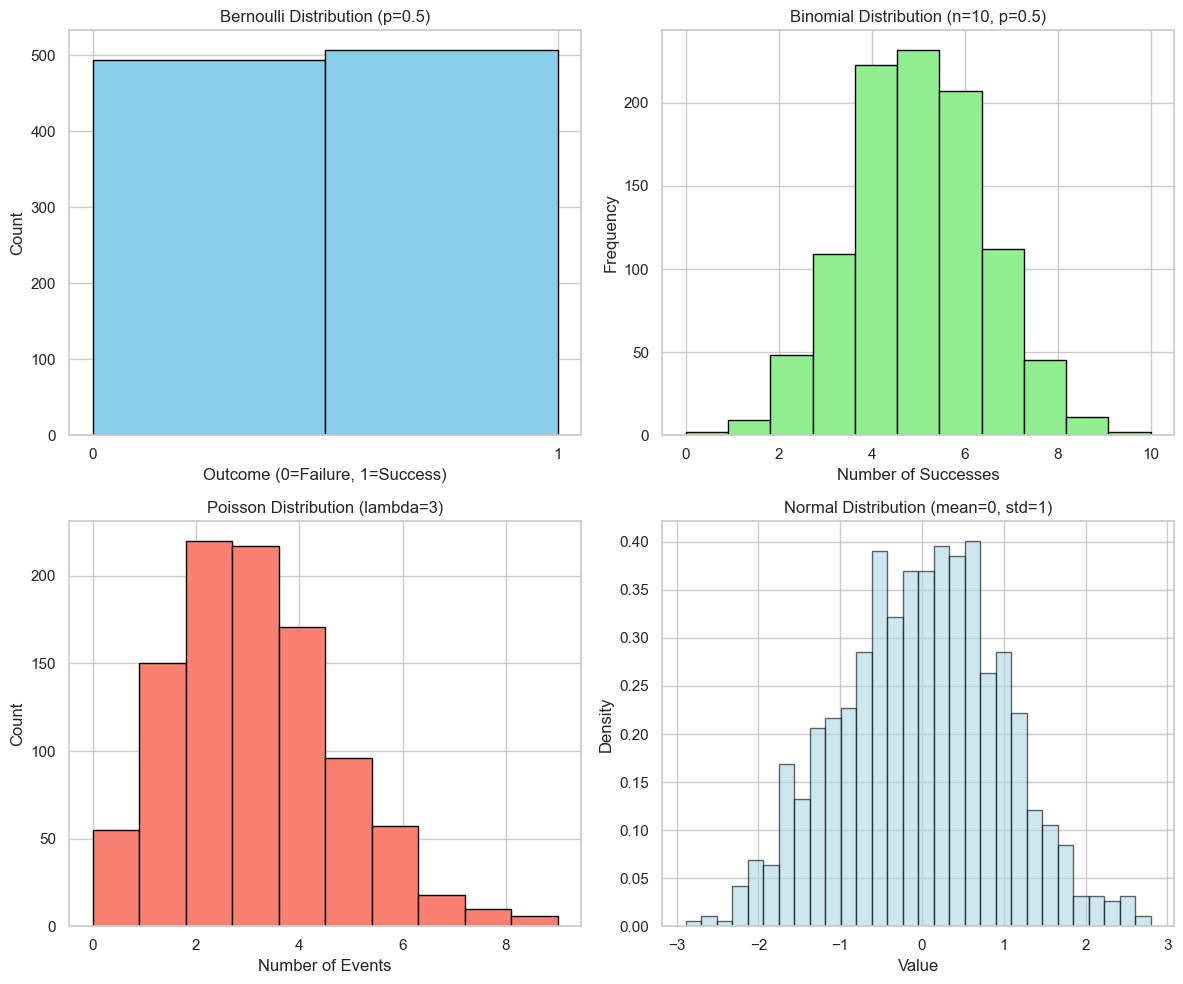

In [128]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli, binom, poisson, norm

# Sample sizes
size = 1000

# ==============================
# Generate Data
# ==============================
# Bernoulli
p_bern = 0.5
bernoulli_data = bernoulli.rvs(p_bern, size=size)

# Binomial
n_binom = 10
p_binom = 0.5
binomial_data = binom.rvs(n_binom, p_binom, size=size)

# Poisson
lambda_poisson = 3
poisson_data = poisson.rvs(mu=lambda_poisson, size=size)

# Normal
mu, sigma = 0, 1
normal_data = norm.rvs(loc=mu, scale=sigma, size=size)

# ==============================
# Plot all distributions
# ==============================
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# Bernoulli
axes[0,0].hist(bernoulli_data, bins=2, edgecolor='black', color='skyblue')
axes[0,0].set_title('Bernoulli Distribution (p=0.5)')
axes[0,0].set_xlabel('Outcome (0=Failure, 1=Success)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xticks([0,1])

# Binomial
axes[0,1].hist(binomial_data, bins=n_binom+1, edgecolor='black', color='lightgreen')
axes[0,1].set_title('Binomial Distribution (n=10, p=0.5)')
axes[0,1].set_xlabel('Number of Successes')
axes[0,1].set_ylabel('Frequency')

# Poisson
axes[1,0].hist(poisson_data, bins=max(poisson_data)-min(poisson_data)+1, edgecolor='black', color='salmon')
axes[1,0].set_title('Poisson Distribution (lambda=3)')
axes[1,0].set_xlabel('Number of Events')
axes[1,0].set_ylabel('Count')

# Normal
axes[1,1].hist(normal_data, bins=30, density=True, alpha=0.6, edgecolor='black', color='lightblue')
axes[1,1].set_title('Normal Distribution (mean=0, std=1)')
axes[1,1].set_xlabel('Value')
axes[1,1].set_ylabel('Density')

plt.tight_layout()
plt.show()


### Train-Validation-Test Split

In [129]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("Train.csv")  # replace with your dataset

# Features and target
X = df.drop(columns=['Reached.on.Time_Y.N'])  # replace with target column for regression
y = df['Cost_of_the_Product']  # target variable (numeric) for regression

# Step 1: Split into Train+Validation (80%) and Test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 2: Split Train+Validation into Train (70%) and Validation (30%) of 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.3, random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (6159, 11)
Validation shape: (2640, 11)
Test shape: (2200, 11)


### Simple Linear Regression

In [131]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Use a single feature (example: 'Weight_in_gms')
feature = ['Weight_in_gms']
X_train_simple = X_train[feature]
X_val_simple = X_val[feature]
X_test_simple = X_test[feature]

# Model
lr_simple = LinearRegression()
lr_simple.fit(X_train_simple, y_train)

# Predictions
y_pred_train = lr_simple.predict(X_train_simple)
y_pred_val = lr_simple.predict(X_val_simple)
y_pred_test = lr_simple.predict(X_test_simple)

# Performance Metrics
def print_metrics(y_true, y_pred, dataset=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"=== {dataset} Metrics ===")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.2f}\n")

print_metrics(y_train, y_pred_train, "Train")
print_metrics(y_val, y_pred_val, "Validation")
print_metrics(y_test, y_pred_test, "Test")


=== Train Metrics ===
MSE: 2305.54
RMSE: 48.02
R²: 0.02

=== Validation Metrics ===
MSE: 2252.59
RMSE: 47.46
R²: 0.02

=== Test Metrics ===
MSE: 2188.28
RMSE: 46.78
R²: 0.01



### Model is underfitting:
### Both Train and Validation R² are extremely low (≈0.02).
### Model fails to capture the relationship between features and target.

In [132]:
# Simple/Multiple Linear Regression might not be sufficient:
# Either the features are weak predictors, or there is multicollinearity / non-linearity in the data.

### Check Correlation Matrix
### Look for features with correlation > 0.8 or < -0.8 → high multicollinearity.

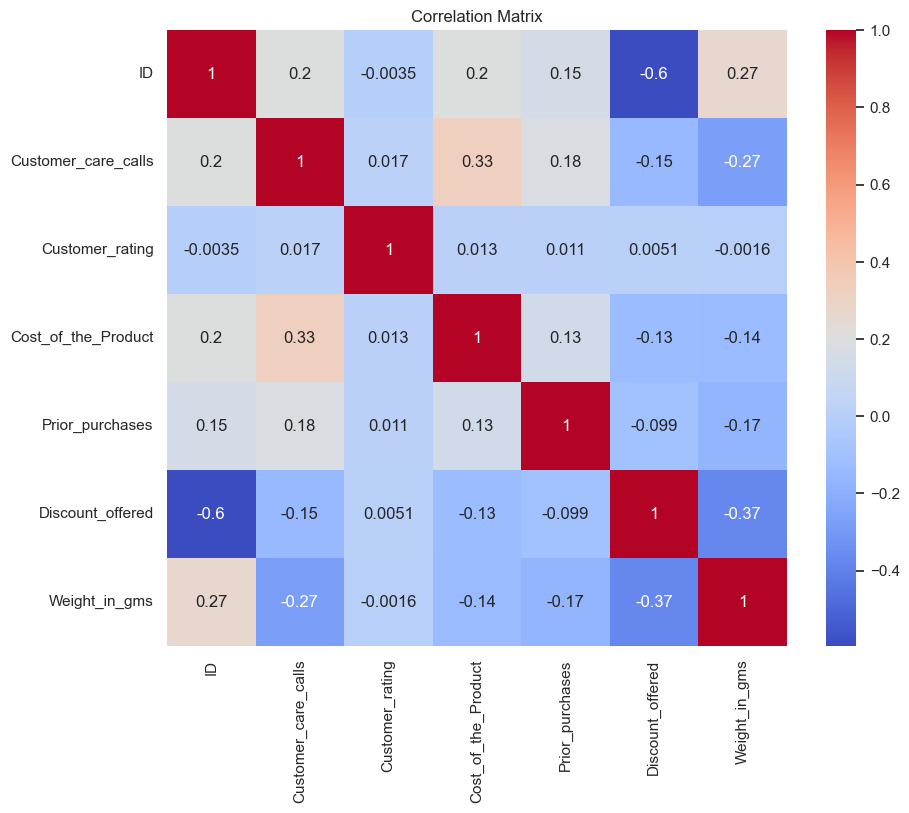

In [135]:
# Select only numeric columns for multiple linear regression
X_train_multi = X_train.select_dtypes(include=['int64','float64'])
X_val_multi = X_val[X_train_multi.columns]
X_test_multi = X_test[X_train_multi.columns]

# Now you can calculate correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X_train_multi.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Observations from the correlation matrix
# High correlations: ID and Discount_offered: -0.6 → moderately high negative correlation
# Other correlations are mostly low (< 0.33), so no severe multicollinearity is immediately visible among numeric features.
# Implication:
# You might consider dropping ID if it’s just an identifier—it usually doesn’t help regression and may introduce spurious correlations.
# Other features like Customer_care_calls, Cost_of_the_Product, Weight_in_gms, etc., seem fairly independent.
# Next step:
# Calculate VIF to quantify multicollinearity, especially for features like Discount_offered and ID.
# Remove features with VIF > 10 if found.

### Calculate VIF (Variance Inflation Factor)

In [136]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# VIF dataframe
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_multi.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_multi.values, i)
                   for i in range(X_train_multi.shape[1])]

print("=== VIF Values ===")
print(vif_data)

# VIF = 1 → No multicollinearity

# VIF between 1–5 → Moderate correlation (usually acceptable)

# VIF > 5 → High correlation (potential multicollinearity problem)

# VIF > 10 → Very high correlation → needs attention

=== VIF Values ===
               feature        VIF
0                   ID   6.410474
1  Customer_care_calls  14.248376
2      Customer_rating   5.132808
3  Cost_of_the_Product  18.019775
4      Prior_purchases   6.526524
5     Discount_offered   2.198041
6        Weight_in_gms   5.151318


In [137]:
# High VIF (>10): 
# Customer_care_calls → 14.25
# Cost_of_the_Product → 18.02
# These are strongly correlated with other features → can affect regression stability.
# Moderate VIF (5–10):
# ID → 6.41
# Prior_purchases → 6.53
# Customer_rating → 5.13
# Weight_in_gms → 5.15
# These are borderline and can be considered depending on domain knowledge.
# Low VIF (<5):
# Discount_offered → 2.20
# Safe to keep.

In [139]:
# Cost_of_the_Product → 18.02  highest
# Customer_care_calls → 14.25  next highest
# These two are causing the most multicollinearity.

### Remove Highly Collinear Features

In [141]:
# Example: remove features with VIF > 10
features_to_keep = vif_data[vif_data['VIF'] <= 10]['feature'].tolist()

X_train_filtered = X_train_multi[features_to_keep]
X_val_filtered = X_val_multi[features_to_keep]
X_test_filtered = X_test_multi[features_to_keep]

print("Features after removing multicollinearity:", features_to_keep)


Features after removing multicollinearity: ['ID', 'Customer_rating', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']


### Retrain Multiple Linear Regression

In [162]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Example with one feature: 'Customer_rating'
X_train_simple = X_train_filtered[['Customer_rating']]
X_val_simple = X_val_filtered[['Customer_rating']]
X_test_simple = X_test_filtered[['Customer_rating']]

lr_simple = LinearRegression()
lr_simple.fit(X_train_simple, y_train)

y_pred_train_simple = lr_simple.predict(X_train_simple)
y_pred_val_simple = lr_simple.predict(X_val_simple)
y_pred_test_simple = lr_simple.predict(X_test_simple)

def print_metrics(y_true, y_pred, dataset=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"=== {dataset} Metrics ===")
    print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}\n")

print_metrics(y_train, y_pred_train_simple, "Train (Simple LR)")
print_metrics(y_val, y_pred_val_simple, "Validation (Simple LR)")
print_metrics(y_test, y_pred_test_simple, "Test (Simple LR)")


=== Train (Simple LR) Metrics ===
MSE: 2350.19, RMSE: 48.48, R²: 0.00

=== Validation (Simple LR) Metrics ===
MSE: 2292.49, RMSE: 47.88, R²: -0.00

=== Test (Simple LR) Metrics ===
MSE: 2217.14, RMSE: 47.09, R²: -0.00



### Check Multicollinearity (Correlation + VIF)

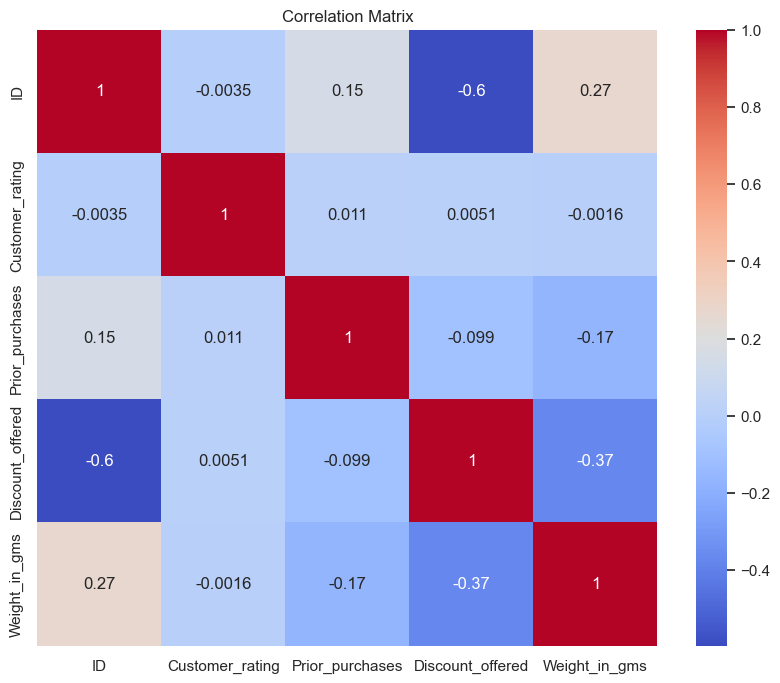

=== VIF Values ===
            Feature       VIF
0                ID  5.164037
1   Customer_rating  4.634228
2   Prior_purchases  5.123430
3  Discount_offered  1.858583
4     Weight_in_gms  4.732676


In [163]:
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(X_train_filtered.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# VIF calculation
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_filtered.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_filtered.values, i) 
                   for i in range(X_train_filtered.shape[1])]
print("=== VIF Values ===")
print(vif_data)


### Train Multiple Linear Regression

In [164]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize and fit model
lr_multi = LinearRegression()
lr_multi.fit(X_train_filtered, y_train)

# Predictions
y_pred_train_multi = lr_multi.predict(X_train_filtered)
y_pred_val_multi = lr_multi.predict(X_val_filtered)
y_pred_test_multi = lr_multi.predict(X_test_filtered)

# Performance function
def print_metrics(y_true, y_pred, dataset=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"=== {dataset} Metrics ===")
    print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}\n")

# Evaluate
print_metrics(y_train, y_pred_train_multi, "Train (Multiple LR)")
print_metrics(y_val, y_pred_val_multi, "Validation (Multiple LR)")
print_metrics(y_test, y_pred_test_multi, "Test (Multiple LR)")


=== Train (Multiple LR) Metrics ===
MSE: 2144.88, RMSE: 46.31, R²: 0.09

=== Validation (Multiple LR) Metrics ===
MSE: 2089.39, RMSE: 45.71, R²: 0.09

=== Test (Multiple LR) Metrics ===
MSE: 2044.49, RMSE: 45.22, R²: 0.08



In [169]:
coefficients = pd.DataFrame({"Feature": X_train_filtered.columns, "Coefficient": lr_multi.coef_})
print(coefficients)

            Feature  Coefficient
0                ID     0.002943
1   Customer_rating     0.441020
2   Prior_purchases     1.842703
3  Discount_offered    -0.272476
4     Weight_in_gms    -0.006369


### Import and Initialize Regularization Models

In [171]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler

# Scaling features for regularization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filtered)
X_val_scaled = scaler.transform(X_val_filtered)
X_test_scaled = scaler.transform(X_test_filtered)


### Train Ridge Regression

In [173]:
ridge = Ridge(alpha=1.0)  # alpha is regularization strength
ridge.fit(X_train_scaled, y_train)

# Predictions
y_pred_train_ridge = ridge.predict(X_train_scaled)
y_pred_val_ridge = ridge.predict(X_val_scaled)
y_pred_test_ridge = ridge.predict(X_test_scaled)

# Coefficients
ridge_coeff = pd.DataFrame({"Feature": X_train_filtered.columns, "Ridge_Coefficient": ridge.coef_})
print("=== Ridge Coefficients ===")
print(ridge_coeff)


=== Ridge Coefficients ===
            Feature  Ridge_Coefficient
0                ID           9.331596
1   Customer_rating           0.620468
2   Prior_purchases           2.798494
3  Discount_offered          -4.428496
4     Weight_in_gms         -10.413667


### Train Lasso Regression

In [174]:
lasso = Lasso(alpha=0.01)  # smaller alpha to prevent zeroing all coefficients
lasso.fit(X_train_scaled, y_train)

# Predictions
y_pred_train_lasso = lasso.predict(X_train_scaled)
y_pred_val_lasso = lasso.predict(X_val_scaled)
y_pred_test_lasso = lasso.predict(X_test_scaled)

# Coefficients
lasso_coeff = pd.DataFrame({"Feature": X_train_filtered.columns, "Lasso_Coefficient": lasso.coef_})
print("=== Lasso Coefficients ===")
print(lasso_coeff)


=== Lasso Coefficients ===
            Feature  Lasso_Coefficient
0                ID           9.327056
1   Customer_rating           0.610579
2   Prior_purchases           2.792908
3  Discount_offered          -4.417707
4     Weight_in_gms         -10.401041


### Train ElasticNet Regression

In [175]:
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)  # l1_ratio=0.5 mixes L1 & L2
elastic.fit(X_train_scaled, y_train)

# Predictions
y_pred_train_elastic = elastic.predict(X_train_scaled)
y_pred_val_elastic = elastic.predict(X_val_scaled)
y_pred_test_elastic = elastic.predict(X_test_scaled)

# Coefficients
elastic_coeff = pd.DataFrame({"Feature": X_train_filtered.columns, "ElasticNet_Coefficient": elastic.coef_})
print("=== ElasticNet Coefficients ===")
print(elastic_coeff)


=== ElasticNet Coefficients ===
            Feature  ElasticNet_Coefficient
0                ID                9.272225
1   Customer_rating                0.612262
2   Prior_purchases                2.804320
3  Discount_offered               -4.406978
4     Weight_in_gms              -10.333691


### Evaluate Performance

In [176]:
def print_metrics(y_true, y_pred, dataset=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"=== {dataset} Metrics ===")
    print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}\n")

# Ridge
print_metrics(y_train, y_pred_train_ridge, "Train (Ridge)")
print_metrics(y_val, y_pred_val_ridge, "Validation (Ridge)")
print_metrics(y_test, y_pred_test_ridge, "Test (Ridge)")

# Lasso
print_metrics(y_train, y_pred_train_lasso, "Train (Lasso)")
print_metrics(y_val, y_pred_val_lasso, "Validation (Lasso)")
print_metrics(y_test, y_pred_test_lasso, "Test (Lasso)")

# ElasticNet
print_metrics(y_train, y_pred_train_elastic, "Train (ElasticNet)")
print_metrics(y_val, y_pred_val_elastic, "Validation (ElasticNet)")
print_metrics(y_test, y_pred_test_elastic, "Test (ElasticNet)")


=== Train (Ridge) Metrics ===
MSE: 2144.88, RMSE: 46.31, R²: 0.09

=== Validation (Ridge) Metrics ===
MSE: 2089.39, RMSE: 45.71, R²: 0.09

=== Test (Ridge) Metrics ===
MSE: 2044.48, RMSE: 45.22, R²: 0.08

=== Train (Lasso) Metrics ===
MSE: 2144.88, RMSE: 46.31, R²: 0.09

=== Validation (Lasso) Metrics ===
MSE: 2089.37, RMSE: 45.71, R²: 0.09

=== Test (Lasso) Metrics ===
MSE: 2044.46, RMSE: 45.22, R²: 0.08

=== Train (ElasticNet) Metrics ===
MSE: 2144.89, RMSE: 46.31, R²: 0.09

=== Validation (ElasticNet) Metrics ===
MSE: 2089.46, RMSE: 45.71, R²: 0.09

=== Test (ElasticNet) Metrics ===
MSE: 2044.27, RMSE: 45.21, R²: 0.08



In [177]:
# Compare Coefficients
coeff_comparison = ridge_coeff.merge(lasso_coeff, on="Feature").merge(elastic_coeff, on="Feature")
print("=== Coefficient Comparison ===")
print(coeff_comparison)


=== Coefficient Comparison ===
            Feature  Ridge_Coefficient  Lasso_Coefficient  \
0                ID           9.331596           9.327056   
1   Customer_rating           0.620468           0.610579   
2   Prior_purchases           2.798494           2.792908   
3  Discount_offered          -4.428496          -4.417707   
4     Weight_in_gms         -10.413667         -10.401041   

   ElasticNet_Coefficient  
0                9.272225  
1                0.612262  
2                2.804320  
3               -4.406978  
4              -10.333691  


### Logistic Regression 

 Logistic Regression - Baseline
Accuracy: 0.6559090909090909
Precision: 0.7297520661157024
Recall: 0.6725057121096725
F1-Score: 0.6999603646452636
ROC-AUC: 0.7337414168092726


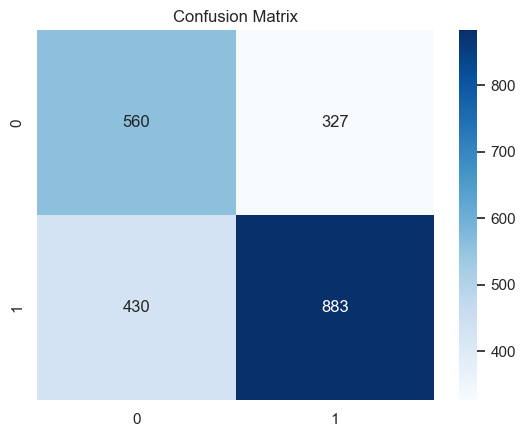

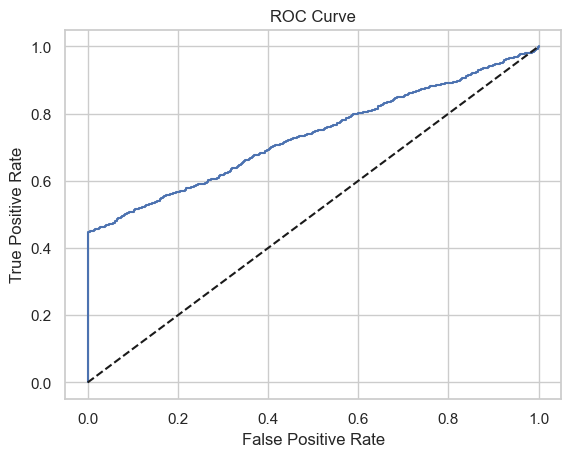

                      Feature  Coefficient  Odds_Ratio
5            Discount_offered     1.483744    4.409424
9           Warehouse_block_D     0.036396    1.037067
2             Customer_rating     0.029774    1.030222
10          Warehouse_block_F     0.017797    1.017956
7           Warehouse_block_B     0.015942    1.016069
15                   Gender_M     0.012188    1.012263
8           Warehouse_block_C    -0.002280    0.997722
12      Mode_of_Shipment_Ship    -0.016186    0.983945
11      Mode_of_Shipment_Road    -0.023491    0.976782
3         Cost_of_the_Product    -0.037372    0.963317
4             Prior_purchases    -0.068100    0.934167
1         Customer_care_calls    -0.091522    0.912541
13     Product_importance_low    -0.114961    0.891401
14  Product_importance_medium    -0.128834    0.879120
6               Weight_in_gms    -0.325661    0.722050
0                          ID    -0.515955    0.596930


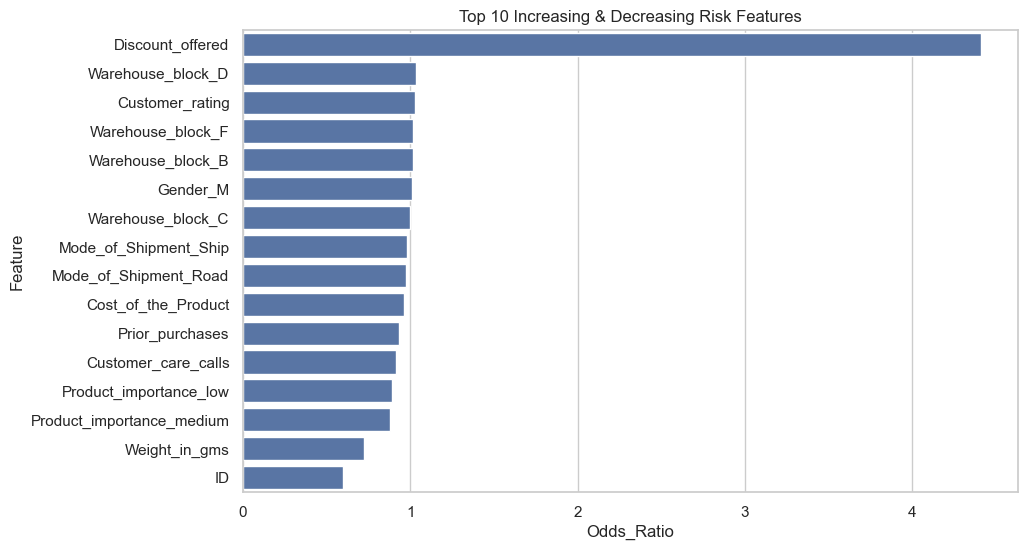

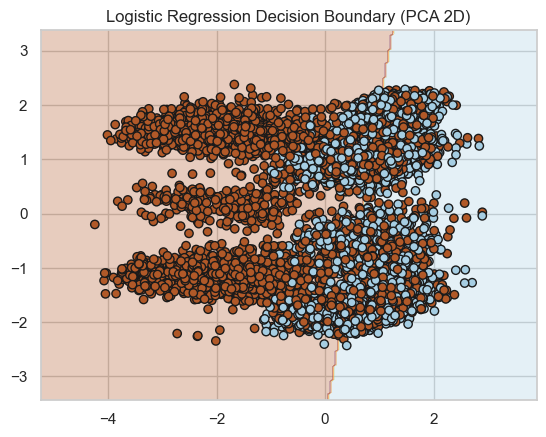

Best Parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}
Best F1 Score (CV): 0.7051251142616313
 Logistic Regression - Best Model
Accuracy: 0.655
Precision: 0.7205414012738853
Recall: 0.6892612338156893
F1-Score: 0.7045543012845465
ROC-AUC: 0.7351770646668344


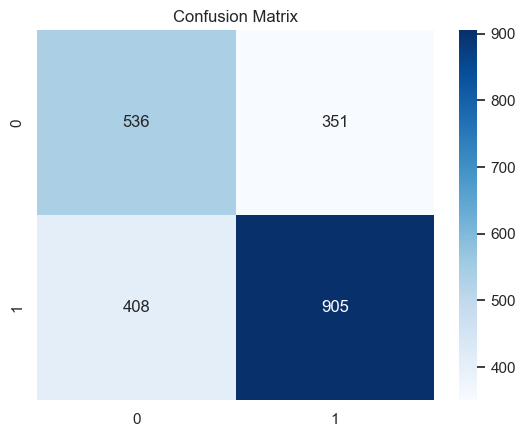

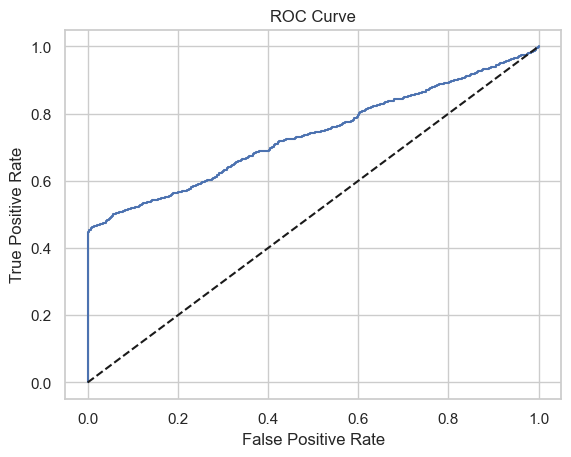

 SVM Model Performance
Accuracy: 0.6731818181818182
Precision: 0.8731155778894473
Recall: 0.5293221629855294
F1-Score: 0.6590801327643433
ROC-AUC: 0.7374142539568327


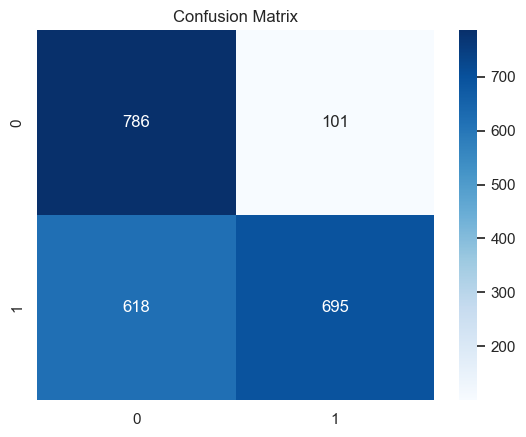

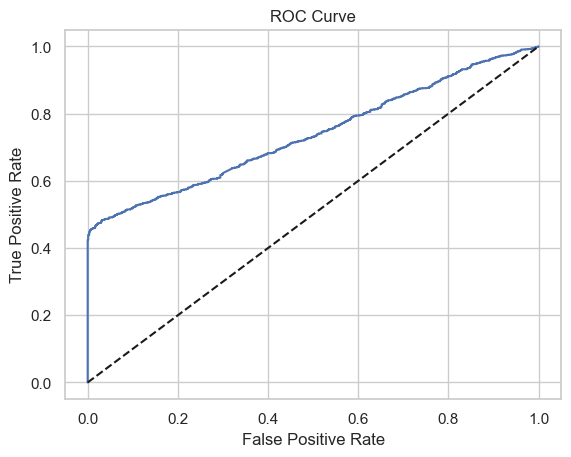

🔹 Naive Bayes Performance
Accuracy: 0.6786363636363636
Precision: 0.9764150943396226
Recall: 0.472962680883473
F1-Score: 0.6372498717290919
ROC-AUC: 0.7356870974583366


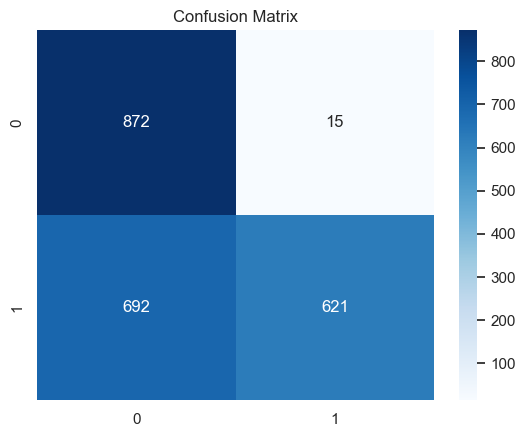

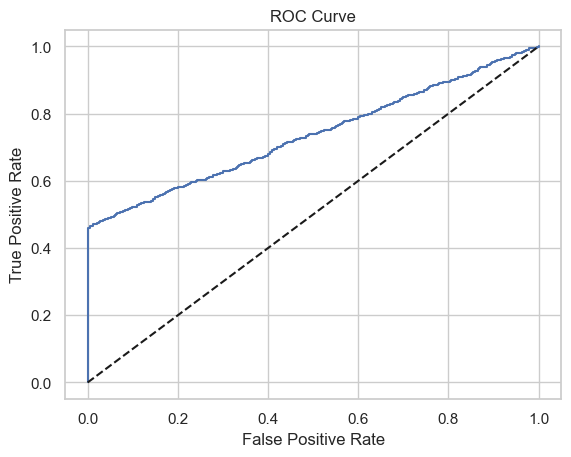

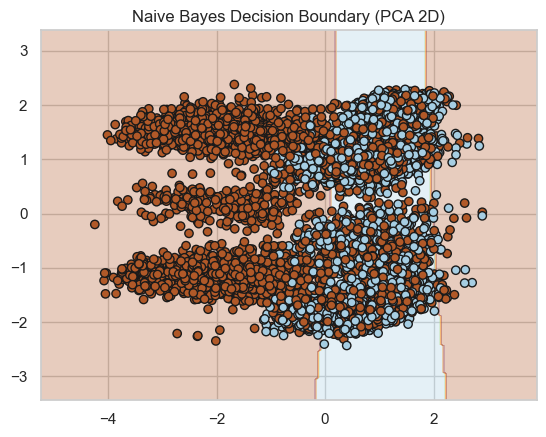

In [186]:
# ----------------------------
# Imports
# ----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score, roc_curve)

# ----------------------------
# 1. Define Features and Target
# ----------------------------

y_class = df['Reached.on.Time_Y.N']
X_features = df.drop(columns=['Reached.on.Time_Y.N'])

# If there are categorical variables, encode them
X_features = pd.get_dummies(X_features, drop_first=True)

# ----------------------------
# 2. Scale Features
# ----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# ----------------------------
# 3. Evaluation Function
# ----------------------------
def evaluate_model(y_true, y_pred, y_prob=None):
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-Score:", f1_score(y_true, y_pred))
    if y_prob is not None:
        print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()
    
    # ROC Curve
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.plot(fpr, tpr, label='ROC Curve')
        plt.plot([0,1],[0,1],'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.show()

# ----------------------------
# 4. Logistic Regression - Baseline
# ----------------------------
logreg = LogisticRegression(solver='liblinear', max_iter=1000)
logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)
y_prob_logreg = logreg.predict_proba(X_test)[:,1]

print(" Logistic Regression - Baseline")
evaluate_model(y_test, y_pred_logreg, y_prob_logreg)

# Coefficients & Odds Ratios
coefficients = pd.DataFrame({
    "Feature": X_features.columns,
    "Coefficient": logreg.coef_[0],
    "Odds_Ratio": np.exp(logreg.coef_[0])
}).sort_values(by="Odds_Ratio", ascending=False)
print(coefficients)

# Plot top 10 increasing & decreasing risk features
top_features = pd.concat([coefficients.head(10), coefficients.tail(10)])
plt.figure(figsize=(10,6))
sns.barplot(x="Odds_Ratio", y="Feature", data=top_features)
plt.title("Top 10 Increasing & Decreasing Risk Features")
plt.show()

# ----------------------------
# 5. Logistic Regression - PCA 2D Decision Boundary
# ----------------------------
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

logreg_2d = LogisticRegression(solver='liblinear')
logreg_2d.fit(X_train_2d, y_train)

xx, yy = np.meshgrid(np.linspace(X_train_2d[:,0].min()-1, X_train_2d[:,0].max()+1, 200),
                     np.linspace(X_train_2d[:,1].min()-1, X_train_2d[:,1].max()+1, 200))
Z = logreg_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
plt.scatter(X_train_2d[:,0], X_train_2d[:,1], c=y_train, edgecolor='k', cmap=plt.cm.Paired)
plt.title("Logistic Regression Decision Boundary (PCA 2D)")
plt.show()

# ----------------------------
# 6. Logistic Regression - GridSearchCV
# ----------------------------
param_grid = {
    'C':[0.01,0.1,1,10],
    'solver':['liblinear','saga'],
    'penalty':['l1','l2']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best F1 Score (CV):", grid.best_score_)

best_logreg = grid.best_estimator_
y_pred_best = best_logreg.predict(X_test)
y_prob_best = best_logreg.predict_proba(X_test)[:,1]

print(" Logistic Regression - Best Model")
evaluate_model(y_test, y_pred_best, y_prob_best)

# ----------------------------
# 7. Support Vector Machine (SVM)
# ----------------------------
svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:,1]

print(" SVM Model Performance")
evaluate_model(y_test, y_pred_svm, y_prob_svm)

# ----------------------------
# 8. Naive Bayes
# ----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:,1]

print("🔹 Naive Bayes Performance")
evaluate_model(y_test, y_pred_nb, y_prob_nb)

# Decision Boundary (2D PCA)
nb_model_2d = GaussianNB()
nb_model_2d.fit(X_train_2d, y_train)
Z_nb = nb_model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z_nb, alpha=0.3, cmap=plt.cm.Paired)
plt.scatter(X_train_2d[:,0], X_train_2d[:,1], c=y_train, edgecolor='k', cmap=plt.cm.Paired)
plt.title("Naive Bayes Decision Boundary (PCA 2D)")
plt.show()


### single ROC curve plot comparing Logistic Regression, SVM, and Naive Bayes

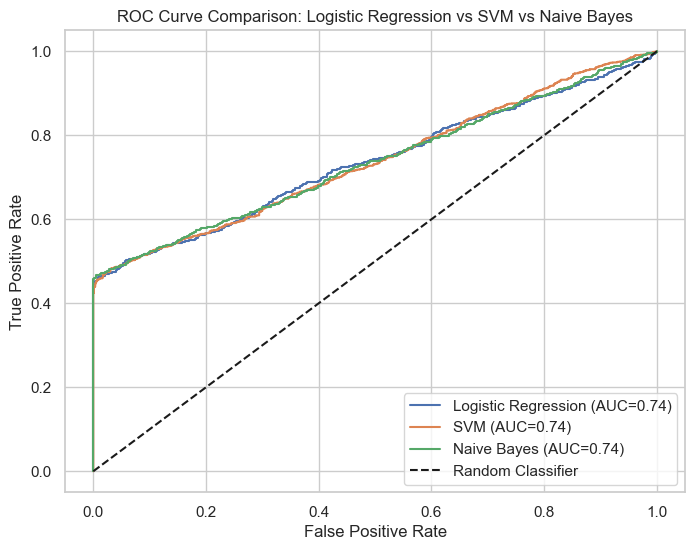

In [187]:
# ----------------------------
# ROC Curve Comparison
# ----------------------------
plt.figure(figsize=(8,6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_best)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_best):.2f})')

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC={roc_auc_score(y_test, y_prob_svm):.2f})')

# Naive Bayes
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC={roc_auc_score(y_test, y_prob_nb):.2f})')

# Random classifier line
plt.plot([0,1],[0,1],'k--', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Logistic Regression vs SVM vs Naive Bayes")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [188]:
#summary table comparing Logistic Regression, SVM, and Naive Bayes on all key metrics

 Model Performance Summary


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.655000,0.720541,0.689261,0.704554,0.735177
SVM,0.673182,0.873116,0.529322,0.659080,0.737414
Naive Bayes,0.678636,0.976415,0.472963,0.637250,0.735687


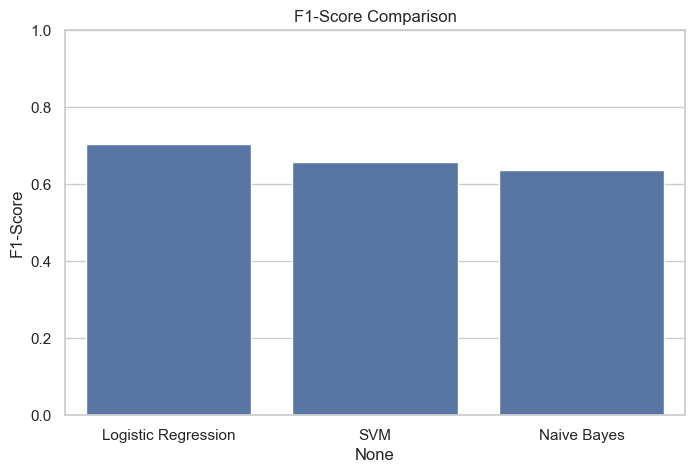

In [189]:
# ----------------------------
# 1. Collect Metrics for Each Model
# ----------------------------
def get_metrics(y_true, y_pred, y_prob=None):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }
    if y_prob is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_prob)
    else:
        metrics["ROC-AUC"] = np.nan
    return metrics

# Logistic Regression (best model from GridSearchCV)
metrics_lr = get_metrics(y_test, y_pred_best, y_prob_best)

# SVM
metrics_svm = get_metrics(y_test, y_pred_svm, y_prob_svm)

# Naive Bayes
metrics_nb = get_metrics(y_test, y_pred_nb, y_prob_nb)

# ----------------------------
# 2. Create Summary Table
# ----------------------------
summary_df = pd.DataFrame([metrics_lr, metrics_svm, metrics_nb],
                          index=["Logistic Regression", "SVM", "Naive Bayes"])

print(" Model Performance Summary")
display(summary_df)

# Optional: plot bar chart for F1-Score comparison
plt.figure(figsize=(8,5))
sns.barplot(x=summary_df.index, y=summary_df["F1-Score"])
plt.title("F1-Score Comparison")
plt.ylabel("F1-Score")
plt.ylim(0,1)
plt.show()
